In [1]:
import os
import sys
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

os.chdir(r'D:\proyecto_eutrofizacion')
sys.path.insert(0, 'src')

from superpixels_slic import aplicar_slic, visualizar_superpixeles, exportar_superpixeles_csv
from water_masc1 import *
from water_masc2 import *

# ================================================================
# CARGAR DATOS
# ================================================================

BASE_PATH = r'D:\proyecto_eutrofizacion'
CSV_RIVER = Path(BASE_PATH) / 'data' / 'metadata' / 'river_water_index.csv'

df_river = pd.read_csv(CSV_RIVER)

# Filtra solo imágenes con máscaras
df_river_con_mask = df_river[df_river['segmentation_mask_path'].notna()].copy()

# Extrae nombre de archivo de la ruta
df_river_con_mask['filename'] = df_river_con_mask['filepath'].apply(
    lambda x: Path(x).name
)

print(f"✓ Cargadas {len(df_river_con_mask)} imágenes con máscaras")
print(f"✓ Años disponibles: {sorted(df_river_con_mask['group'].unique())}")

✓ Cargadas 7630 imágenes con máscaras
✓ Años disponibles: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [11]:
print(df_river_con_mask.loc[df_river_con_mask[df_river_con_mask['filename'] == 'DJI_3317.JPG'].index[0]])

filepath                  data/raw/external/river_water_dataset\2019\ima...
source                                                  river_water_dataset
group                                                                  2019
has_gps                                                                True
site                                                          basento_river
segmentation_mask_path    data/raw/external/river_water_dataset\2019\lab...
mask_type                                            water_polygon_labelimg
mask_format                                                         polygon
filename                                                       DJI_3317.JPG
Name: 1851, dtype: object


Aplicando SLIC (n_segments=50, compactness=20)...
✓ SLIC completado
  Superpíxeles creados: 23
  Tamaño promedio: 276890 píxeles/superpíxel


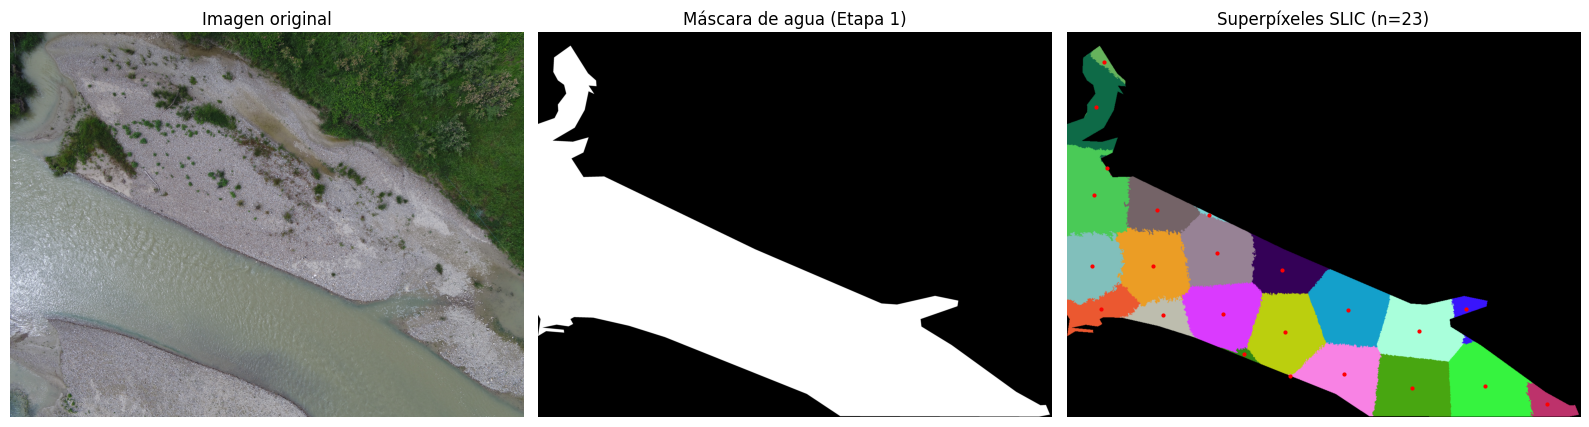

In [20]:
# Cargar imagen y máscara (ejemplo con una imagen de RivAIrSet)
row = df_river_con_mask.loc[df_river_con_mask[df_river_con_mask['filename'] == 'DJI_3317.JPG'].index[0]]  # Primera imagen
ruta_imagen = Path(BASE_PATH) / row['filepath']
ruta_mascara = Path(BASE_PATH) / row['segmentation_mask_path']

imagen_bgr = cv2.imread(str(ruta_imagen))
mascara_agua = cargar_mascara_desde_labeling(str(ruta_mascara), imagen_bgr.shape[0], imagen_bgr.shape[1])

# APLICAR ETAPA 2
resultado_slic = aplicar_slic(
    imagen_bgr,
    mascara_agua,
    n_segments=50,    # Ajusta según necesites (100-500)
    compactness=20     # Ajusta según necesites (1-20)
)

# Visualizar
fig, axes = visualizar_superpixeles(resultado_slic)
plt.show()

# Extraer información de cada superpíxel
imagen_hsv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV)
imagen_lab = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2LAB)

#df_superpixeles = exportar_superpixeles_csv(
#    resultado_slic,
#    imagen_hsv,
#    imagen_lab,
#    'output/superpixeles_info.csv'
#)
#
#print(df_superpixeles.head(10))